# Brain CTA Analysis - Texture Features & PCA

### Contact
- **Alexander R. Webber** (alexander.webber@fda.hhs.gov)
- **Seyed M. Kahaki** (seyed.kahaki@fda.hhs.gov)

---

## Input format

| Item | Details |
|---|---|
| **Root directory** | `experiment_root` - a tree organized as `<root>/<condition>/<case>/ct_simulation/` |
| **CT file** | `MIDA_deformed_<idx>.h5` - dataset key `"reconstruction"`; shape `(Z, Y, X)`, dtype `float32`, values in Hounsfield Units (HU) |
| **Mask file** | `MIDA_deformed_<idx>.mask.h5` - dataset key `"masks/Blood Arteries"`; shape `(Z, Y, X)`, dtype `uint8`, binary `{0, 1}` |
| **Naming convention** | Case folders are `case_<NNNN>`; the zero-padded index `<NNNN>` picks the matching CT/mask filenames |
| **CT preprocessing** | Brain window applied before feature extraction: **center = 40 HU, width = 80 HU** → clipped to `[0, 80]` HU, then normalized to `uint8` `[0, 255]` |
| **Analysis slice** | Middle axial slice (`volume[Z // 2]`) |

Filenames, dataset keys, and the window are all configurable; the values above are the defaults.


## Texture features

Two families are extracted from the masked region of the middle axial slice.

### 1 · Local Binary Pattern (LBP) - histogram

| Parameter | Value |
|---|---|
| Method | `"uniform"` |
| Radius | `3` pixels |
| Sampling points | `24` (`8 × radius`) |
| Output | Normalized histogram over the masked pixels; **26** bins (`n_points + 2`, the number of codes the `uniform` method can produce) |

### 2 · Gray-Level Co-occurrence Matrix (GLCM) - property means

| Parameter | Value |
|---|---|
| Distances | `[1, 3, 5]` pixels |
| Angles | `[0°, 45°, 90°, 135°]` (`[0, π/4, π/2, 3π/4]` radians) |
| Levels | `256` |
| Normalization | Symmetric, normed |
| ROI | Bounding box of the mask on the slice |
| Properties (6) | `contrast`, `dissimilarity`, `homogeneity`, `energy`, `correlation`, `ASM` |
| Output | One mean value per property, averaged over all distance–angle combinations |

**Combined feature vector:** 26 LBP bins + 6 GLCM means → **32 features per case**.


## 1 · Imports


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from IPython.display     import display
from matplotlib          import pyplot as plt

from src.brain_pipeline  import run_cta_analysis


## 2 · Configuration

Defaults to processing all experiments. Can select different experiments by modifying the 'conditions' list. 


In [ ]:
cta_settings = {
    'experiment_root' : '/projects01/didsr-aiml/SDDT/ScoreCard/Brain/Synthetic',

    # Case shown in the three-plane viewer; defaults to the first one found.
    'viewer_condition': '26_07_23_15_21_mA_300',
    'viewer_case'     : 'case_0000',

    # 'conditions'             : ['26_07_23_15_21_mA_300'],  # restrict to some conditions
    # 'max_cases_per_condition': 5,                          # quick trial run
    'mask_dataset'           : 'masks/Blood Arteries',
    # 'window_center'          : 40,
    # 'window_width'           : 80,
    # 'n_components'           : 2,
    # 'save_outputs'           : False,
}


## 3 · Run

Extracting features touches every case in the tree, so this is the slow cell. Set
`max_cases_per_condition` above for a quick trial run first. Outputs are written to
`data/notebook_outputs/brain_cta/`.


CTA TEXTURE FEATURES AND PCA


findfont: Failed to find font weight semibold, now using 700.


Found 147 case(s) across 7 condition(s).
  26_07_23_15_20_sampleCount_1
  26_07_23_15_21_mA_300
  26_07_23_15_21_mA_50
  26_07_23_15_27_crosstalkCallback
  26_07_23_15_29_thickness0.5
  26_07_23_15_31_thickness3
  26_07_28_09_41_temp

Feature table: 100 sample(s) × 32 feature(s); 47 skipped.


findfont: Failed to find font weight semibold, now using 700.



Saved 4 output file(s) to /home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_cta


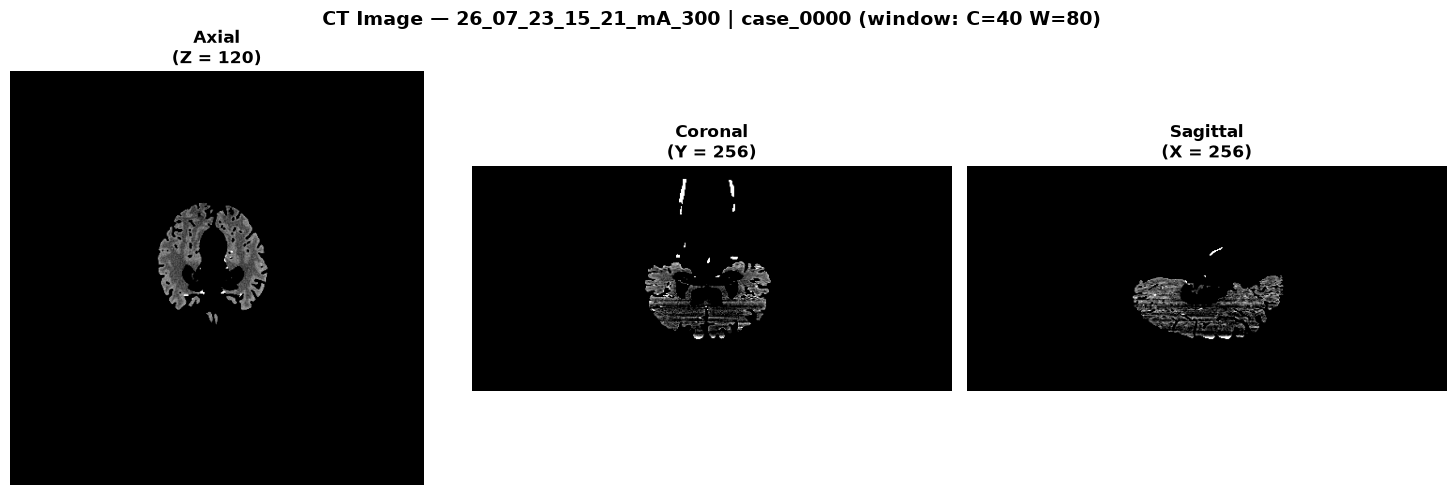

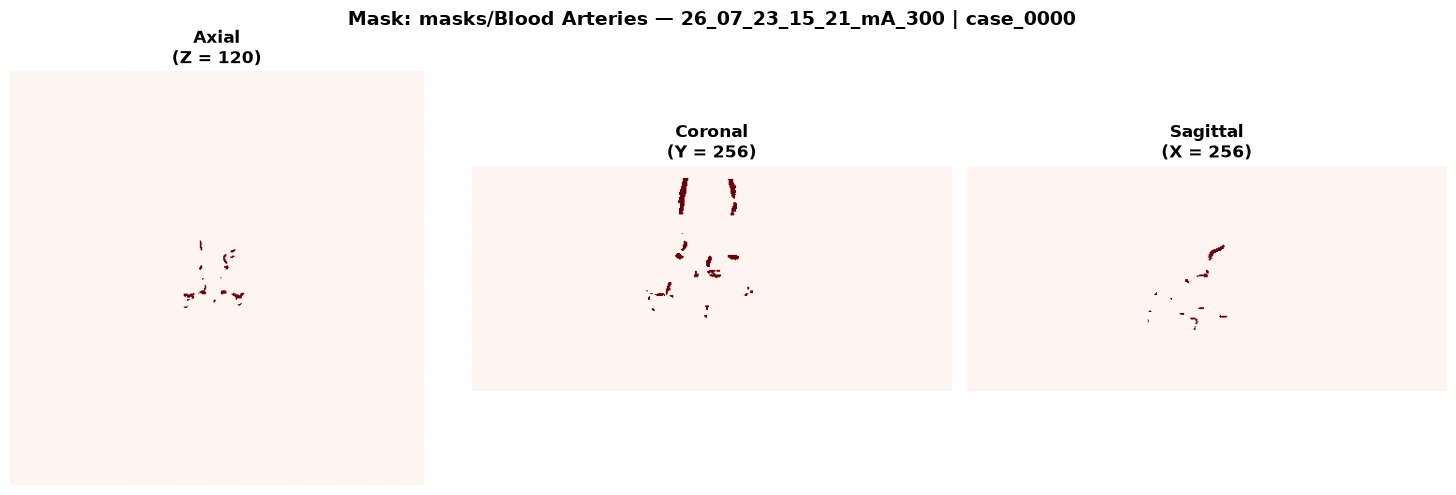

In [4]:
results = run_cta_analysis(**cta_settings)


## 4 · Results

The three-plane viewer confirms the CT window and the mask land where expected before reading
anything into the feature space. The PCA scatter is interactive: click a condition in the legend to
hide it, double-click to isolate it. It is also saved as
`data/notebook_outputs/brain_cta/cta_texture_pca.html`.


--- viewer_ct ---


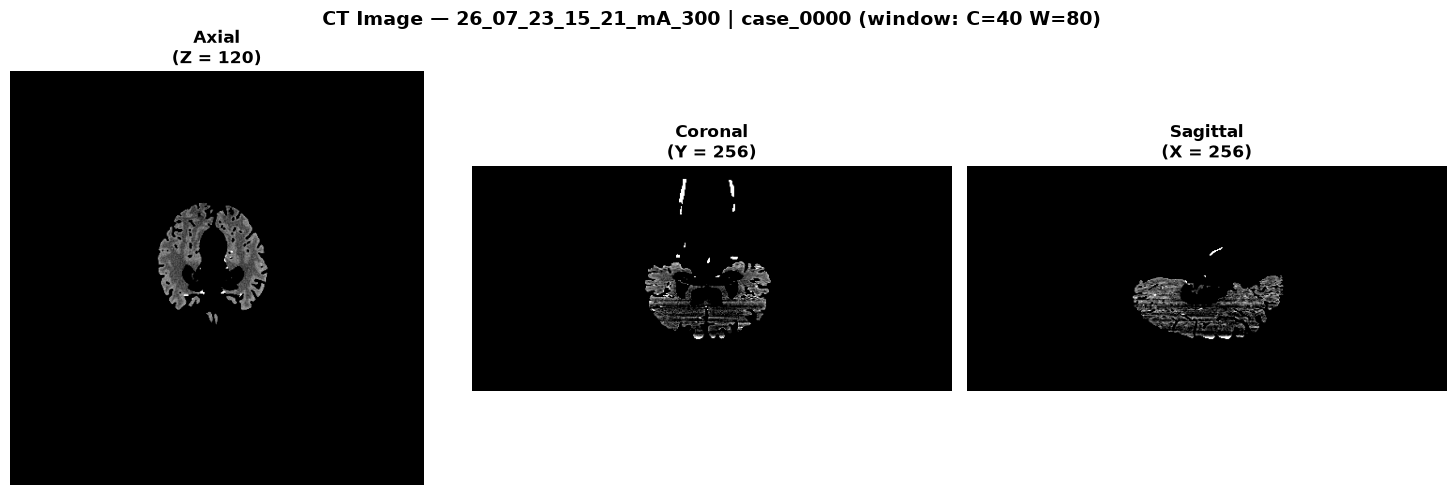

--- viewer_mask ---


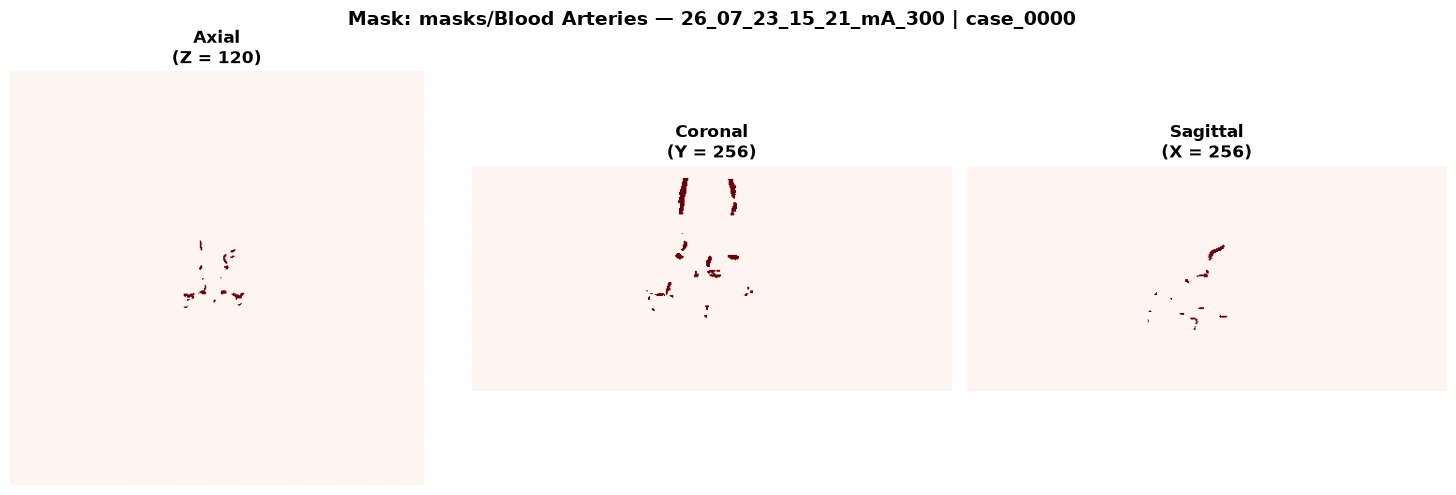

In [5]:
for name, fig in results['figures'].items():
    print(f'--- {name} ---')
    display(fig)
    plt.close(fig)

if results['pca_figure'] is not None:
    results['pca_figure'].show()


In [ ]:
features = results['features']
variance = results['pca']['explained_variance_ratio'] * 100

print(f'Feature table: {features.shape[0]} case(s) × {features.shape[1] - 2} feature(s)')
print(f'PC1 {variance[0]:.1f}% variance, PC2 {variance[1]:.1f}% variance')

if results['skipped']:
    print(f"\n{len(results['skipped'])} case(s) skipped:")

    for condition, case, reason in results['skipped'][:10]:
        print(f'  {condition}/{case} - {reason}')

display(features.head(10))


Feature table: 100 case(s) × 32 feature(s)
PC1 40.1% variance, PC2 17.4% variance

47 case(s) skipped:
  26_07_23_15_20_sampleCount_1/case_0002 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0003 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0004 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0005 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0006 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0008 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0009 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0011 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0013 — missing CT or mask file
  26_07_23_15_20_sampleCount_1/case_0014 — missing CT or mask file


,condition,case,lbp_00,lbp_01,lbp_02,lbp_03,lbp_04,lbp_05,lbp_06,lbp_07,...,lbp_22,lbp_23,lbp_24,lbp_25,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,glcm_asm
0,26_07_23_15_20_sampleCount_1,case_0000,0.116343,0.024931,0.052632,0.024931,0.027701,0.005540,0.002770,0.005540,...,0.00277,0.00554,0.603878,0.105263,2495.694716,21.831522,0.625211,0.611049,0.584503,0.373969
1,26_07_23_15_20_sampleCount_1,case_0001,0.029412,0.009804,0.014706,0.000000,0.004902,0.068627,0.039216,0.029412,...,0.00000,0.00000,0.598039,0.088235,4311.270248,17.237936,0.929324,0.905897,0.393429,0.820804
2,26_07_23_15_20_sampleCount_1,case_0007,0.022801,0.009772,0.009772,0.045603,0.052117,0.003257,0.006515,0.016287,...,0.00000,0.00000,0.788274,0.035831,2979.684785,18.880185,0.795820,0.786136,0.422762,0.618348
3,26_07_23_15_20_sampleCount_1,case_0010,0.027778,0.013889,0.027778,0.083333,0.111111,0.020833,0.000000,0.034722,...,0.00000,0.00000,0.583333,0.062500,4707.286373,18.672227,0.924425,0.906239,0.307380,0.821416
4,26_07_23_15_20_sampleCount_1,case_0012,0.025424,0.002825,0.008475,0.031073,0.022599,0.036723,0.025424,0.000000,...,0.00000,0.00000,0.782486,0.053672,2127.708322,14.273777,0.835380,0.828528,0.488104,0.686783
5,26_07_23_15_20_sampleCount_1,case_0019,0.024390,0.000000,0.004065,0.085366,0.032520,0.012195,0.004065,0.004065,...,0.00000,0.00000,0.658537,0.166667,3745.644914,20.678186,0.751375,0.730631,0.537289,0.534123
6,26_07_23_15_21_mA_300,case_0000,0.116343,0.024931,0.052632,0.024931,0.027701,0.005540,0.002770,0.005540,...,0.00277,0.00554,0.603878,0.105263,2495.652156,21.833268,0.625207,0.611049,0.584496,0.373969
7,26_07_23_15_21_mA_300,case_0001,0.029412,0.009804,0.014706,0.000000,0.004902,0.068627,0.039216,0.029412,...,0.00000,0.00000,0.598039,0.088235,4318.601554,17.240772,0.929325,0.905897,0.393457,0.820804
8,26_07_23_15_21_mA_300,case_0007,0.022801,0.009772,0.013029,0.035831,0.055375,0.003257,0.006515,0.016287,...,0.00000,0.00000,0.788274,0.039088,2978.799413,18.875420,0.795706,0.785750,0.421068,0.617745
9,26_07_23_15_21_mA_300,case_0010,0.027778,0.013889,0.027778,0.083333,0.111111,0.020833,0.000000,0.034722,...,0.00000,0.00000,0.583333,0.062500,4707.552334,18.661503,0.924425,0.906239,0.307164,0.821416


## 5 · Saved outputs


In [7]:
for path in results['saved_paths']:
    print(path)


/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_cta/cta_viewer_ct.svg
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_cta/cta_viewer_mask.svg
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_cta/cta_texture_features.csv
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_cta/cta_texture_pca.html
